In [100]:
# !pip install matplotlib
# ! pip install seaborn

In [101]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
titanic_df = pd.read_csv('titanic.csv')

# Bar Chart

In [102]:
info_count = titanic_df.Survived.value_counts()
info_count

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: title={'center': 'Count of Survived Passengers'}, xlabel='Survived (No = 0, Yes = 1)', ylabel='No of Passengers'>

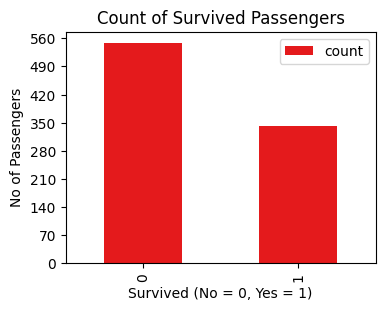

In [103]:
info_count.plot.bar(
    title = "Count of Survived Passengers",
    xlabel = "Survived (No = 0, Yes = 1)",
    ylabel = "No of Passengers",
    yticks = list(range(0,600,70)),
    legend = True,
    colormap = "Set1",
    figsize = (4,3)
)

In [104]:
titanic_df[["Sex", "Survived"]].value_counts()

Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

<Axes: title={'center': 'Count of Survived Passengers'}, xlabel='Survived (No = 0, Yes = 1)', ylabel='No of Passengers'>

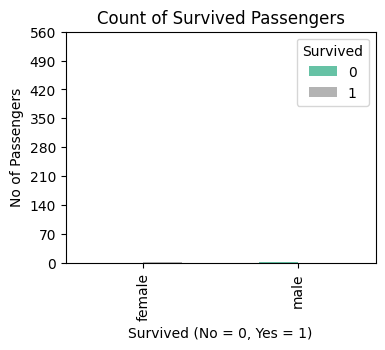

In [105]:
pd.crosstab(
    titanic_df["Sex"],
    titanic_df["Survived"],
    normalize="index"
).plot.bar(
    title = "Count of Survived Passengers",
    xlabel = "Survived (No = 0, Yes = 1)",
    ylabel = "No of Passengers",
    yticks = list(range(0,600,70)),
    legend = True,
    colormap = "Set2",
    figsize = (4,3)  
)


# Pie Chart

In [106]:
group_by_embarked = titanic_df.groupby(by = "Embarked")
counter = group_by_embarked.count()
counter

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
Embarked,,,,,,,,,,,
C,168,168,168,168,168,130,168,168,168,168,69
Q,77,77,77,77,77,28,77,77,77,77,4
S,644,644,644,644,644,554,644,644,644,644,129


<Axes: >

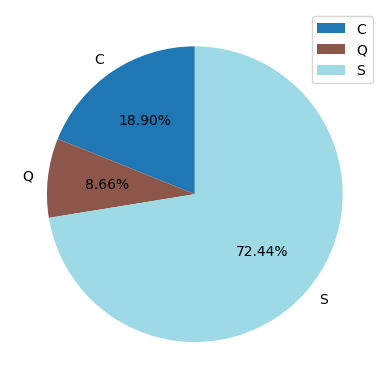

In [107]:
counter.plot(
    kind = "pie",
    y = "Survived",
    colormap = "tab20",
    autopct = "%1.2f%%",
    startangle = 90
)

array([<Axes: >, <Axes: >], dtype=object)

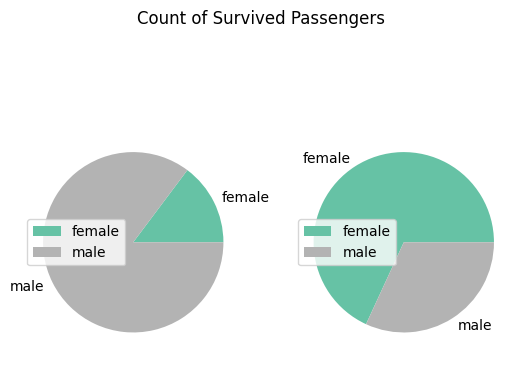

In [108]:
pd.crosstab(
    titanic_df["Sex"],
    titanic_df["Survived"],
    # normalize="all"
).plot.pie(
    title = "Count of Survived Passengers",
    subplots = True,
    legend = True,
    colormap = "Set2",
    # figsize = (4,3)  
)


# Histogram

<Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Number of Passengers'>

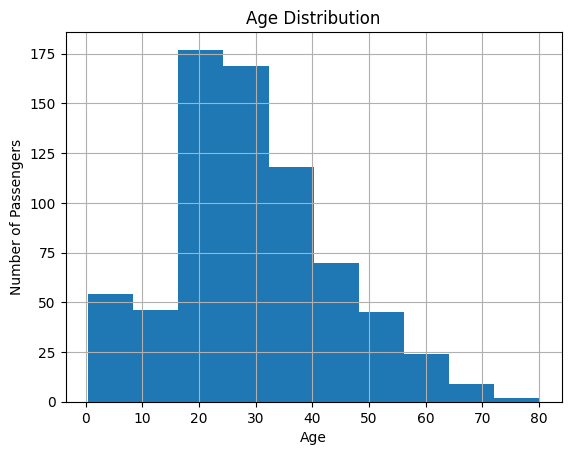

In [109]:
titanic_df.Age.plot(
    kind = "hist",
    bins = 10,
    title = "Age Distribution",
    xlabel = "Age",
    ylabel = "Number of Passengers",
    grid = True
)

In [110]:
titanic_df.Age.mean()

np.float64(29.69911764705882)

array([<Axes: title={'center': 'female'}, ylabel='Total Passengers'>,
       <Axes: title={'center': 'male'}, ylabel='Total Passengers'>],
      dtype=object)

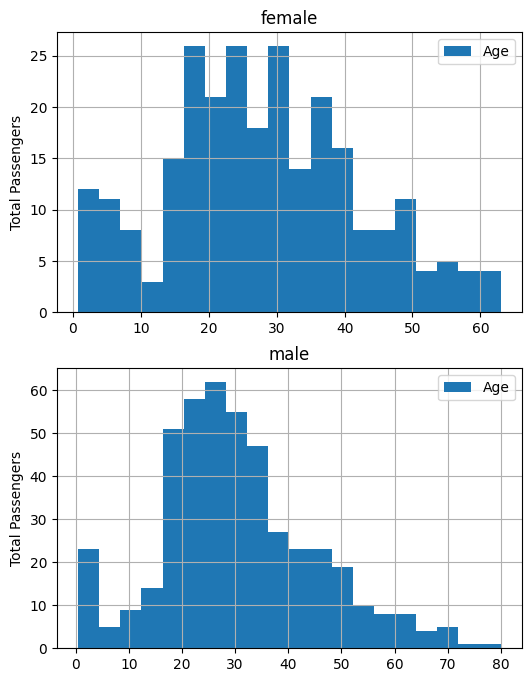

In [111]:
titanic_df[["Age", "Sex"]].plot(
    kind = "hist",
    by = "Sex",
    ylabel = "Total Passengers",
    bins = 20,
    figsize = (6, 8),
    grid = True
)

In [112]:
# ! pip install scipy

<Axes: ylabel='Density'>

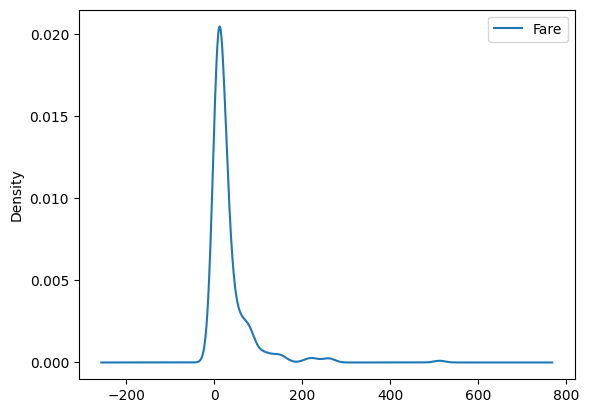

In [113]:
titanic_df.plot(
    kind = "kde",
    x = "Age", y = "Fare"
)

# Scatter Plot

<Axes: xlabel='Age', ylabel='Fare'>

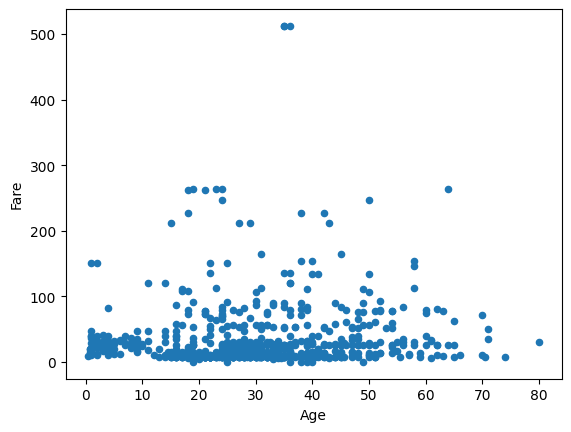

In [114]:
titanic_df.plot(
    kind = "scatter",
    x = "Age", y = "Fare"
)

<Axes: xlabel='Age', ylabel='Fare'>

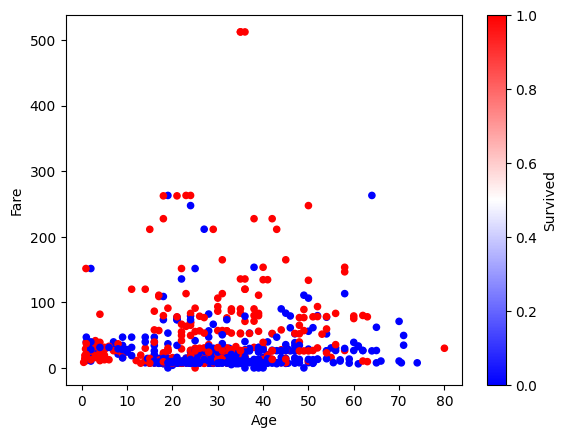

In [115]:
titanic_df.plot(
    kind = "scatter",
    x = "Age", y = "Fare",
    c = "Survived",
    # s = "SiSp"
    colormap="bwr"
)

# Line Chart

<Axes: xlabel='Age'>

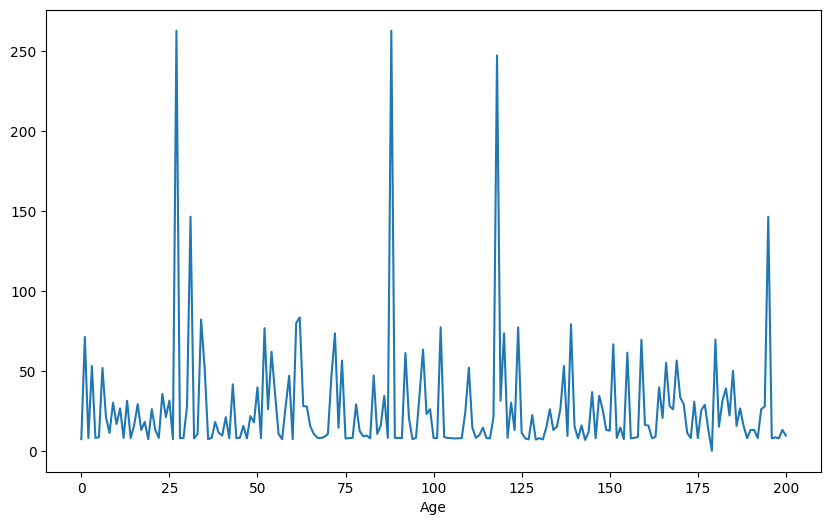

In [116]:
titanic_df.Fare.loc[:200].plot(
    kind = "line",
    xlabel = "Age",
    figsize = (10,6)
)

<Axes: xlabel='Age'>

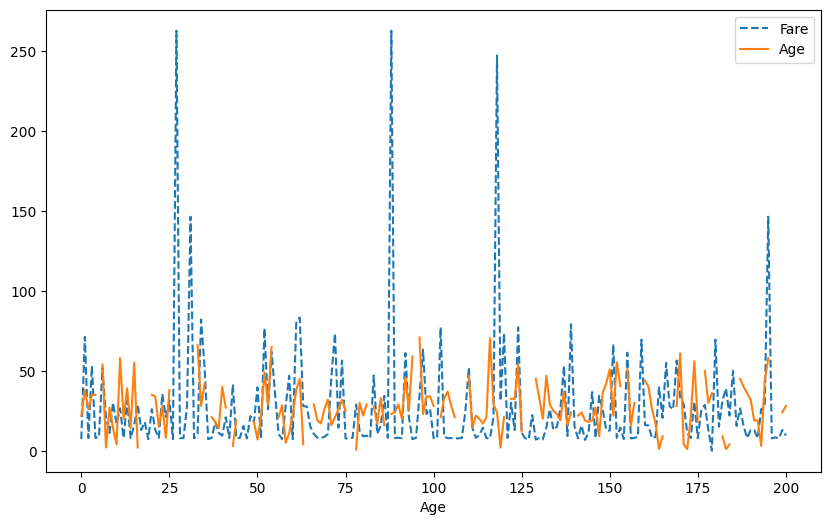

In [117]:
titanic_df[["Fare","Age"]].loc[:200].plot(
    kind = "line",
    xlabel = "Age",
    figsize = (10,6),
    style = ["--", "-"]
)

# Box Plot

In [118]:
titanic_df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

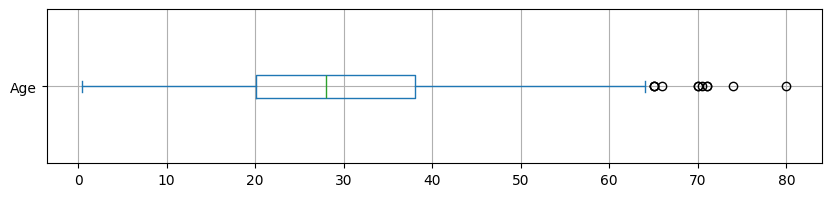

In [119]:
titanic_df.plot(
    kind = "box",
    column = "Age",
    grid = True,
    vert = False,
    figsize = (10, 2)
)

<Axes: >

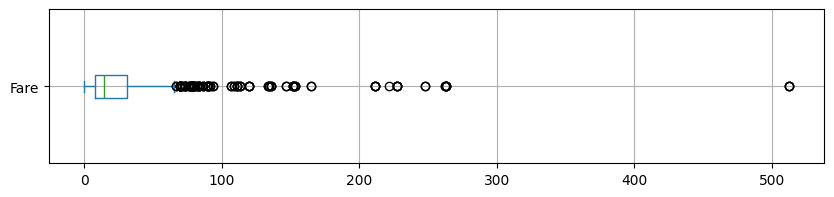

In [120]:
titanic_df.plot(
    kind = "box",
    column = "Fare",
    grid = True,
    vert = False,
    figsize = (10, 2)
)

Age    Axes(0.125,0.11;0.775x0.77)
dtype: object

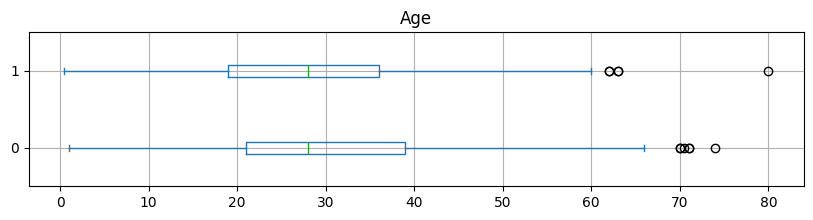

In [121]:
titanic_df.plot(
    kind = "box",
    column = "Age",
    by = "Survived",
    grid = True,
    vert = False,
    figsize = (10, 2)
)

# Heat Map

<Axes: >

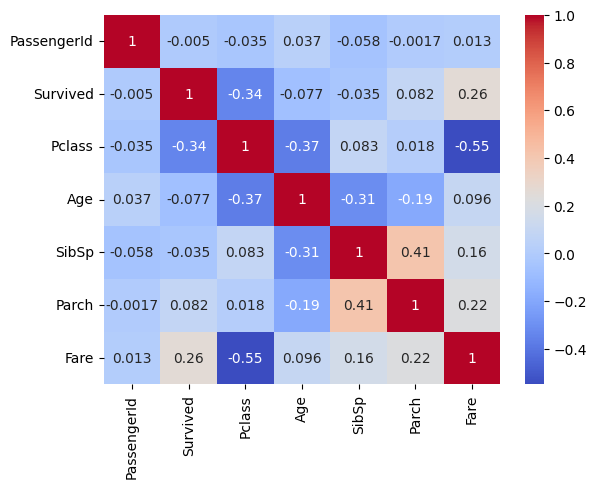

In [122]:
corr = titanic_df.corr(numeric_only=True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

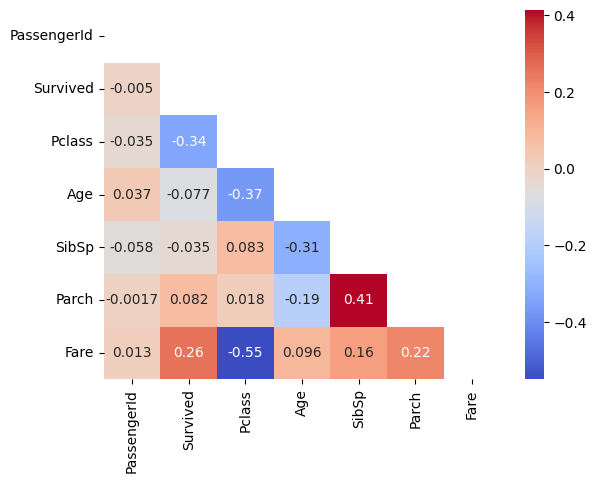

In [ ]:
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask = mask, annot = True, cmap = 'coolwarm')
plt.show()

# Violin Chart

<Axes: xlabel='Age'>

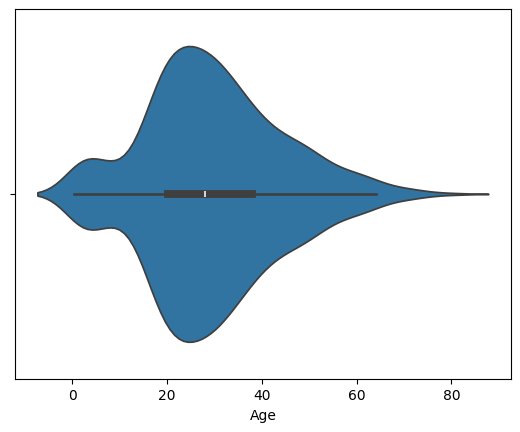

In [124]:
sns.violinplot(x = titanic_df.Age, orient = "h")

# Bubble Chart

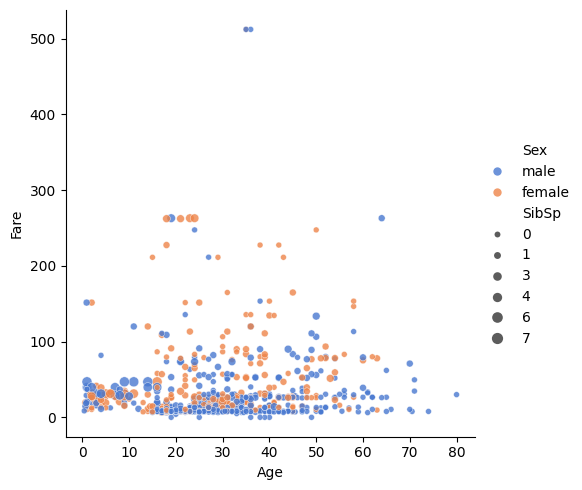

In [128]:
sns.relplot(
    data = titanic_df,
    x = "Age",
    y = "Fare",
    size = "SibSp",
    hue = "Sex",
    palette = "muted",
    alpha = 0.8
)
plt.show()

# Area Plot

<Axes: >

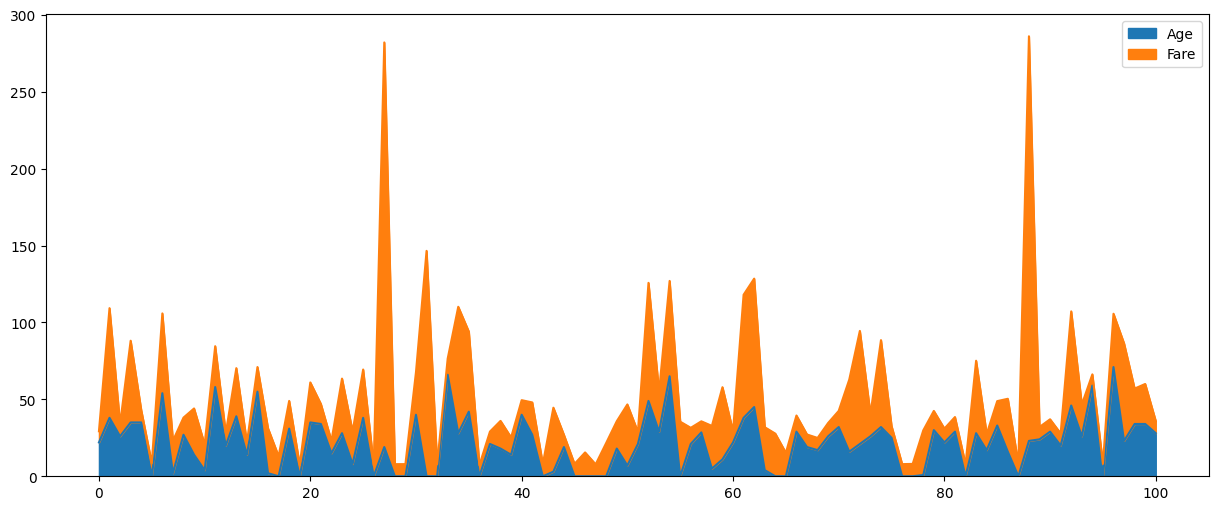

In [133]:
titanic_df[["Age", "Fare"]].loc[:100].plot(
    kind = "area",
    figsize = (15,6)
)

In [134]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [135]:
titanic_df.Age.max()

np.float64(80.0)

In [136]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [137]:
titanic_df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64